# Taller: Análisis y Limpieza de Marketing Data
## Solución Completa

**Dataset:** Marketing Campaign Data (2,206 clientes)

**Objetivo:** Limpiar y preprocesar el dataset aplicando técnicas de:
- Identificación de missing values
- Detección de duplicados
- Detección de outliers
- Creación de variables derivadas

---

## Parte 1: Exploración Inicial (30 min)

### 1.1 Instalación y Carga de Librerías

In [1]:
# Instalación de librerías necesarias (ejecutar solo una vez)
# !pip install pandas numpy matplotlib seaborn scipy

In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


### 1.2 Carga de Datos desde CSV

In [ ]:
# Cargar datos desde CSV
archivo = 'mk_data.csv'

try:
    df = pd.read_csv(archivo)
    
    print("✅ Datos cargados correctamente")
    print(f"\nDimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
    
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo '{archivo}'")
    print("   Asegúrate de que el archivo esté en el mismo directorio que este notebook")
except Exception as e:
    print(f"❌ Error al cargar los datos: {e}")

✅ Datos cargados correctamente

Dimensiones del dataset: 2240 filas x 28 columnas


### 1.3 Limpieza Inicial de Datos

Algunas columnas tienen formatos especiales que necesitamos corregir:

In [4]:
# Limpiar columna Income (quitar $, comas y espacios)
if 'Income' in df.columns:
    # Convertir a string primero
    df['Income'] = df['Income'].astype(str)
    # Quitar $, comas y espacios, luego convertir a float
    df['Income'] = df['Income'].str.replace('$', '', regex=False)
    df['Income'] = df['Income'].str.replace(',', '', regex=False)
    df['Income'] = df['Income'].str.strip()
    df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
    print("✅ Columna 'Income' limpiada y convertida a numérica")

# Convertir Dt_Customer a datetime
if 'Dt_Customer' in df.columns:
    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%m/%d/%y', errors='coerce')
    print("✅ Columna 'Dt_Customer' convertida a fecha")

print("\n✅ Limpieza inicial completada")

✅ Columna 'Income' limpiada y convertida a numérica
✅ Columna 'Dt_Customer' convertida a fecha

✅ Limpieza inicial completada


### 1.4 Primera Inspección del Dataset

In [5]:
# Ver primeras filas
print("=" * 80)
print("PRIMERAS 5 FILAS DEL DATASET")
print("=" * 80)
df.head()

PRIMERAS 5 FILAS DEL DATASET


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [6]:
# Información general del dataset
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)
df.info()

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  M

In [7]:
# Estadísticas descriptivas de variables numéricas
print("=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 80)
df.describe()

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391


In [8]:
# Estadísticas descriptivas de variables categóricas
print("=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS")
print("=" * 80)
df.describe(include='object')

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS


,Education,Marital_Status,Country
count,2240,2240,2240
unique,5,8,8
top,Graduation,Married,SP
freq,1127,864,1095


In [9]:
# Tipos de datos
print("=" * 80)
print("TIPOS DE DATOS POR COLUMNA")
print("=" * 80)
print(df.dtypes)

TIPOS DE DATOS POR COLUMNA
ID                              int64
Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Response               

In [10]:
# Guardar dimensiones originales para comparar después
filas_original = df.shape[0]
columnas_original = df.shape[1]

print(f"\n📊 Dataset original: {filas_original} filas x {columnas_original} columnas")


📊 Dataset original: 2240 filas x 28 columnas


### 1.5 Resumen de Exploración Inicial

**Preguntas respondidas:**
- ✅ ¿Cuántas filas y columnas tiene el dataset?
- ✅ ¿Qué tipos de datos tenemos?
- ✅ ¿Cuáles son las estadísticas básicas de las variables numéricas?

---

## Parte 2: Identificación de Problemas de Calidad (45 min)

### 2.1 Missing Values (Valores Faltantes)

In [11]:
# Identificar missing values
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

# Crear DataFrame con resultados
missing_df = pd.DataFrame({
    'Columna': missing.index,
    'Missing_Count': missing.values,
    'Percentage': missing_percent.values
})

# Filtrar solo columnas con missing values
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage', ascending=False)

print("=" * 80)
print("REPORTE DE VALORES FALTANTES")
print("=" * 80)

if len(missing_df) == 0:
    print("✅ ¡No se encontraron valores faltantes!")
else:
    print(missing_df.to_string(index=False))
    print(f"\n📊 Total de columnas con missing values: {len(missing_df)}")

REPORTE DE VALORES FALTANTES
Columna  Missing_Count  Percentage
 Income             24    1.071429

📊 Total de columnas con missing values: 1


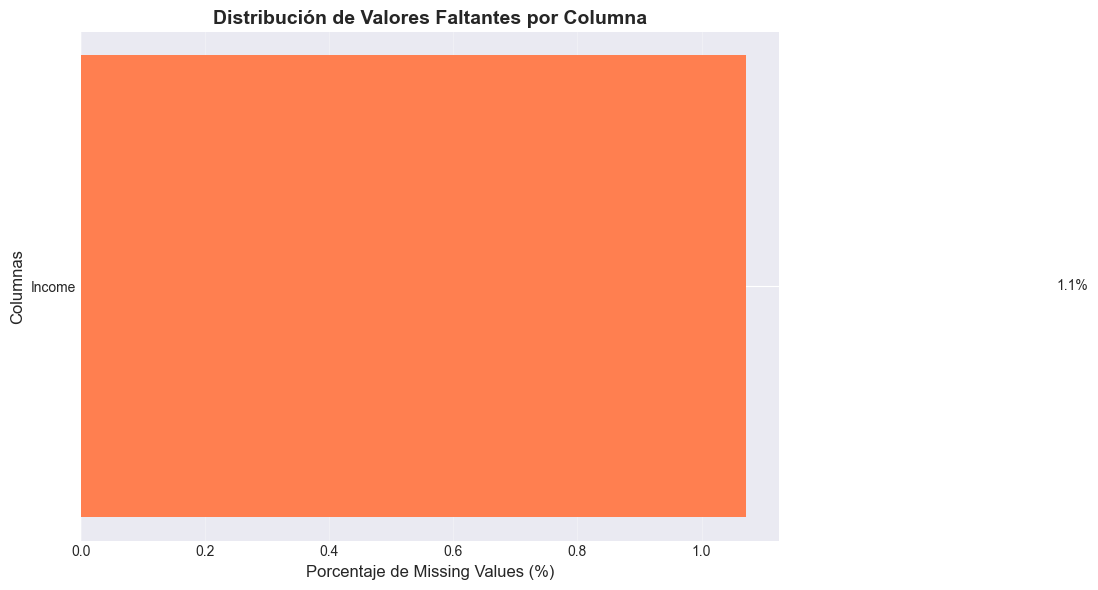

In [12]:
# Visualizar missing values (si existen)
if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(missing_df['Columna'], missing_df['Percentage'], color='coral')
    plt.xlabel('Porcentaje de Missing Values (%)', fontsize=12)
    plt.ylabel('Columnas', fontsize=12)
    plt.title('Distribución de Valores Faltantes por Columna', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    # Añadir valores en las barras
    for i, v in enumerate(missing_df['Percentage']):
        plt.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No hay missing values que visualizar")

### 2.2 Duplicados

In [13]:
# Verificar duplicados completos
duplicados_completos = df.duplicated().sum()

print("=" * 80)
print("REPORTE DE DUPLICADOS")
print("=" * 80)
print(f"Filas completamente duplicadas: {duplicados_completos}")
print(f"Porcentaje del total: {(duplicados_completos/len(df)*100):.2f}%")

# Verificar duplicados por ID si existe
if 'ID' in df.columns:
    duplicados_id = df.duplicated(subset=['ID']).sum()
    print(f"\nIDs duplicados: {duplicados_id}")
    
    if duplicados_id > 0:
        print("\n⚠️ Hay IDs duplicados. Analizando...")
        ids_duplicados = df[df.duplicated(subset=['ID'], keep=False)].sort_values('ID')
        print(f"Registros con IDs duplicados:")
        print(ids_duplicados[['ID']].head(10))

REPORTE DE DUPLICADOS
Filas completamente duplicadas: 0
Porcentaje del total: 0.00%

IDs duplicados: 0


In [14]:
# Analizar duplicados completos si existen
if duplicados_completos > 0:
    print("\n" + "=" * 80)
    print("ANÁLISIS DE REGISTROS DUPLICADOS")
    print("=" * 80)
    duplicados = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
    print(f"\nMostrando primeros 10 registros duplicados:")
    print(duplicados.head(10))
else:
    print("\n✅ No se encontraron filas completamente duplicadas")


✅ No se encontraron filas completamente duplicadas


### 2.3 Detección de Outliers

In [15]:
# Seleccionar solo variables numéricas
numericas = df.select_dtypes(include=[np.number]).columns.tolist()

print("=" * 80)
print("VARIABLES NUMÉRICAS DETECTADAS")
print("=" * 80)
print(f"Total de variables numéricas: {len(numericas)}")
print(f"\nVariables: {numericas}")

VARIABLES NUMÉRICAS DETECTADAS
Total de variables numéricas: 24

Variables: ['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain']


In [16]:
# Función para detectar outliers con método IQR
def detectar_outliers_iqr(df, columna):
    """
    Detecta outliers usando el método del Rango Intercuartílico (IQR)
    
    Parámetros:
    - df: DataFrame
    - columna: nombre de la columna a analizar
    
    Retorna:
    - outliers: DataFrame con los outliers
    - limite_inferior: límite inferior para outliers
    - limite_superior: límite superior para outliers
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    
    return outliers, limite_inferior, limite_superior

print("✅ Función detectar_outliers_iqr definida correctamente")

✅ Función detectar_outliers_iqr definida correctamente


In [17]:
# Analizar outliers para cada variable numérica
print("=" * 80)
print("REPORTE DE OUTLIERS POR VARIABLE (Método IQR)")
print("=" * 80)

outliers_reporte = []

for col in numericas:
    outliers, limite_inf, limite_sup = detectar_outliers_iqr(df, col)
    n_outliers = len(outliers)
    porcentaje = (n_outliers / len(df)) * 100
    
    outliers_reporte.append({
        'Variable': col,
        'Outliers': n_outliers,
        'Porcentaje': f"{porcentaje:.2f}%",
        'Límite_Inferior': f"{limite_inf:.2f}",
        'Límite_Superior': f"{limite_sup:.2f}"
    })

outliers_df = pd.DataFrame(outliers_reporte)
outliers_df = outliers_df[outliers_df['Outliers'] > 0].sort_values('Outliers', ascending=False)

if len(outliers_df) > 0:
    print(outliers_df.to_string(index=False))
    print(f"\n📊 Total de variables con outliers: {len(outliers_df)}")
else:
    print("✅ No se detectaron outliers en ninguna variable")

REPORTE DE OUTLIERS POR VARIABLE (Método IQR)
           Variable  Outliers Porcentaje Límite_Inferior Límite_Superior
           Response       334     14.91%            0.00            0.00
   MntSweetProducts       248     11.07%          -47.00           81.00
          MntFruits       227     10.13%          -47.00           81.00
    MntFishProducts       223      9.96%          -67.50          120.50
       MntGoldProds       207      9.24%          -61.50          126.50
    MntMeatProducts       175      7.81%         -308.00          556.00
       AcceptedCmp4       167      7.46%            0.00            0.00
       AcceptedCmp3       163      7.28%            0.00            0.00
       AcceptedCmp5       163      7.28%            0.00            0.00
       AcceptedCmp1       144      6.43%            0.00            0.00
  NumDealsPurchases        86      3.84%           -2.00            6.00
           MntWines        35      1.56%         -697.00         1225.00
     

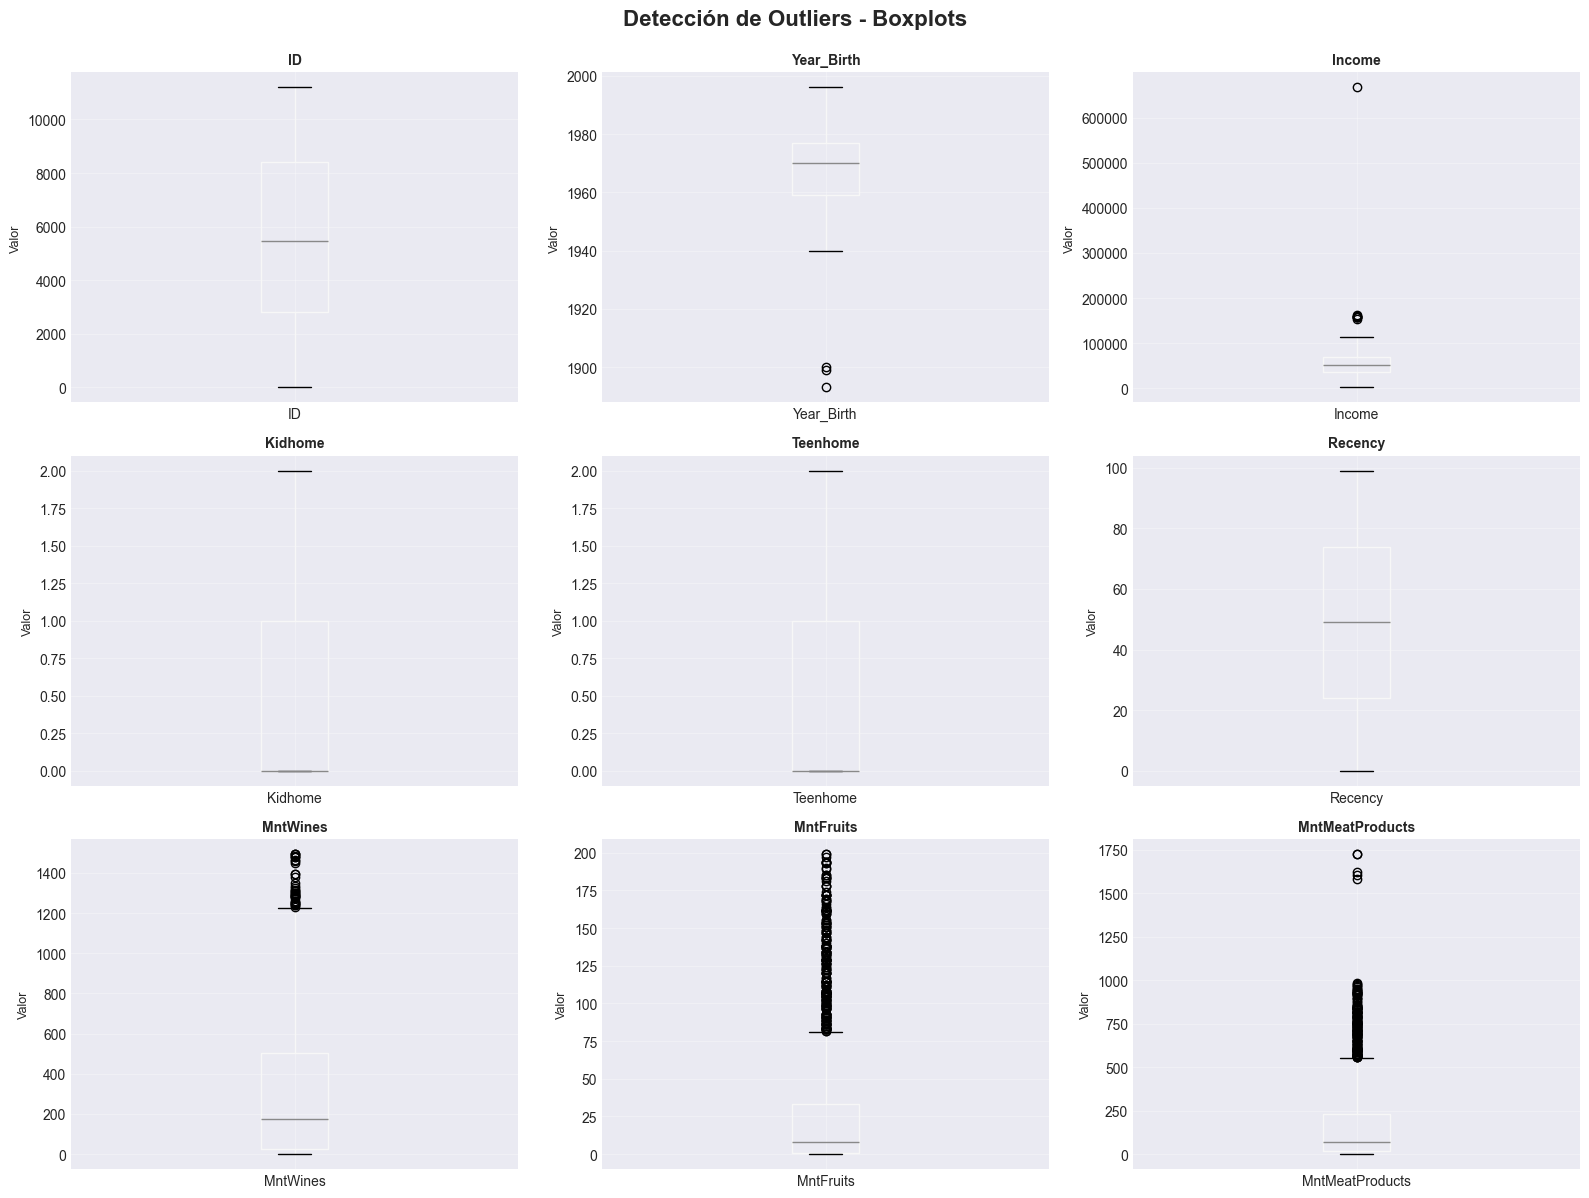

In [18]:
# Visualizar outliers con boxplots
# Seleccionar las primeras 9 variables numéricas más relevantes
vars_to_plot = numericas[:9] if len(numericas) >= 9 else numericas

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(vars_to_plot):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Valor', fontsize=9)
    axes[i].grid(alpha=0.3)

# Ocultar subplots vacíos
for j in range(i+1, 9):
    axes[j].axis('off')

plt.suptitle('Detección de Outliers - Boxplots', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 2.4 Resumen de Problemas Identificados

In [19]:
print("=" * 80)
print("RESUMEN DE PROBLEMAS DE CALIDAD IDENTIFICADOS")
print("=" * 80)

print(f"\n1️⃣ MISSING VALUES:")
if len(missing_df) > 0:
    print(f"   - {len(missing_df)} columnas con valores faltantes")
    print(f"   - Columna más afectada: {missing_df.iloc[0]['Columna']} ({missing_df.iloc[0]['Percentage']:.2f}%)")
else:
    print(f"   - ✅ No hay missing values")

print(f"\n2️⃣ DUPLICADOS:")
if duplicados_completos > 0:
    print(f"   - {duplicados_completos} filas completamente duplicadas ({duplicados_completos/len(df)*100:.2f}%)")
else:
    print(f"   - ✅ No hay duplicados")

print(f"\n3️⃣ OUTLIERS:")
if len(outliers_df) > 0:
    print(f"   - {len(outliers_df)} variables con outliers")
    print(f"   - Variable más afectada: {outliers_df.iloc[0]['Variable']} ({outliers_df.iloc[0]['Outliers']} outliers)")
else:
    print(f"   - ✅ No se detectaron outliers")

print("\n" + "=" * 80)

RESUMEN DE PROBLEMAS DE CALIDAD IDENTIFICADOS

1️⃣ MISSING VALUES:
   - 1 columnas con valores faltantes
   - Columna más afectada: Income (1.07%)

2️⃣ DUPLICADOS:
   - ✅ No hay duplicados

3️⃣ OUTLIERS:
   - 19 variables con outliers
   - Variable más afectada: Response (334 outliers)



---

## Parte 3: Limpieza y Preprocesamiento (60 min)

### 3.1 Tratamiento de Missing Values

In [20]:
# Crear copia del dataset para limpieza
df_clean = df.copy()

print("=" * 80)
print("TRATAMIENTO DE MISSING VALUES")
print("=" * 80)

if len(missing_df) > 0:
    for idx, row in missing_df.iterrows():
        col = row['Columna']
        porcentaje = row['Percentage']
        
        print(f"\n📌 Tratando: {col} ({porcentaje:.2f}% missing)")
        
        # Estrategia según tipo de variable y porcentaje
        if df_clean[col].dtype in ['float64', 'int64']:
            # Variables numéricas: imputar con mediana
            mediana = df_clean[col].median()
            df_clean[col].fillna(mediana, inplace=True)
            print(f"   ✅ Imputado con mediana: {mediana:.2f}")
        else:
            # Variables categóricas: imputar con moda o 'Desconocido'
            if porcentaje < 5:
                moda = df_clean[col].mode()[0]
                df_clean[col].fillna(moda, inplace=True)
                print(f"   ✅ Imputado con moda: {moda}")
            else:
                df_clean[col].fillna('Desconocido', inplace=True)
                print(f"   ✅ Imputado con 'Desconocido'")
    
    # Verificar que no queden missing values
    missing_final = df_clean.isna().sum().sum()
    print(f"\n✅ Missing values después del tratamiento: {missing_final}")
else:
    print("\n✅ No hay missing values que tratar")

TRATAMIENTO DE MISSING VALUES

📌 Tratando: Income (1.07% missing)
   ✅ Imputado con mediana: 51381.50

✅ Missing values después del tratamiento: 0


### 3.2 Tratamiento de Duplicados

In [21]:
print("=" * 80)
print("TRATAMIENTO DE DUPLICADOS")
print("=" * 80)

filas_antes = len(df_clean)

if duplicados_completos > 0:
    # Eliminar duplicados completos
    df_clean = df_clean.drop_duplicates()
    filas_despues = len(df_clean)
    eliminados = filas_antes - filas_despues
    
    print(f"✅ Duplicados completos eliminados: {eliminados}")
    print(f"   Filas antes: {filas_antes}")
    print(f"   Filas después: {filas_despues}")
else:
    print("✅ No hay duplicados que eliminar")

# Verificar duplicados por ID si existe
if 'ID' in df_clean.columns:
    duplicados_id_antes = df_clean.duplicated(subset=['ID']).sum()
    if duplicados_id_antes > 0:
        df_clean = df_clean.drop_duplicates(subset=['ID'], keep='first')
        print(f"\n✅ Duplicados por ID eliminados: {duplicados_id_antes}")
        print(f"   Estrategia: Mantener el primer registro")

TRATAMIENTO DE DUPLICADOS
✅ No hay duplicados que eliminar


### 3.3 Creación de Variables Derivadas

In [22]:
print("=" * 80)
print("CREACIÓN DE VARIABLES DERIVADAS")
print("=" * 80)

# 1. Edad del cliente
if 'Year_Birth' in df_clean.columns:
    df_clean['Edad'] = 2024 - df_clean['Year_Birth']
    print(f"✅ Variable 'Edad' creada")
    print(f"   Rango: {df_clean['Edad'].min():.0f} - {df_clean['Edad'].max():.0f} años")
    print(f"   Promedio: {df_clean['Edad'].mean():.1f} años")

# 2. Antigüedad como cliente
if 'Dt_Customer' in df_clean.columns:
    df_clean['Antiguedad_Cliente'] = (pd.to_datetime('2024-01-01') - df_clean['Dt_Customer']).dt.days
    print(f"\n✅ Variable 'Antiguedad_Cliente' creada (en días)")
    print(f"   Rango: {df_clean['Antiguedad_Cliente'].min():.0f} - {df_clean['Antiguedad_Cliente'].max():.0f} días")
    print(f"   Promedio: {df_clean['Antiguedad_Cliente'].mean():.0f} días ({df_clean['Antiguedad_Cliente'].mean()/365:.1f} años)")

# 3. Total de personas en el hogar
if 'Kidhome' in df_clean.columns and 'Teenhome' in df_clean.columns:
    df_clean['Total_Hogar'] = df_clean['Kidhome'] + df_clean['Teenhome']
    print(f"\n✅ Variable 'Total_Hogar' creada")
    print(f"   Distribución: {df_clean['Total_Hogar'].value_counts().sort_index().to_dict()}")

# 4. Gasto total
gasto_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
if all(col in df_clean.columns for col in gasto_cols):
    df_clean['Gasto_Total'] = df_clean[gasto_cols].sum(axis=1)
    print(f"\n✅ Variable 'Gasto_Total' creada")
    print(f"   Rango: ${df_clean['Gasto_Total'].min():.2f} - ${df_clean['Gasto_Total'].max():.2f}")
    print(f"   Promedio: ${df_clean['Gasto_Total'].mean():.2f}")
    print(f"   Mediana: ${df_clean['Gasto_Total'].median():.2f}")

# 5. Total de compras
compra_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
if all(col in df_clean.columns for col in compra_cols):
    df_clean['Total_Compras'] = df_clean[compra_cols].sum(axis=1)
    print(f"\n✅ Variable 'Total_Compras' creada")
    print(f"   Rango: {df_clean['Total_Compras'].min():.0f} - {df_clean['Total_Compras'].max():.0f}")
    print(f"   Promedio: {df_clean['Total_Compras'].mean():.1f} compras")

# 6. Tasa de aceptación de campañas
campana_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
if all(col in df_clean.columns for col in campana_cols):
    df_clean['Tasa_Aceptacion_Campanas'] = df_clean[campana_cols].sum(axis=1) / len(campana_cols)
    print(f"\n✅ Variable 'Tasa_Aceptacion_Campanas' creada")
    print(f"   Rango: {df_clean['Tasa_Aceptacion_Campanas'].min():.2f} - {df_clean['Tasa_Aceptacion_Campanas'].max():.2f}")
    print(f"   Promedio: {df_clean['Tasa_Aceptacion_Campanas'].mean():.2f}")

print("\n" + "=" * 80)
print(f"✅ Total de variables derivadas creadas: 6")
print(f"✅ Nuevas dimensiones del dataset: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")

CREACIÓN DE VARIABLES DERIVADAS
✅ Variable 'Edad' creada
   Rango: 28 - 131 años
   Promedio: 55.2 años

✅ Variable 'Antiguedad_Cliente' creada (en días)
   Rango: 3473 - 4172 días
   Promedio: 3827 días (10.5 años)

✅ Variable 'Total_Hogar' creada
   Distribución: {0: 638, 1: 1128, 2: 421, 3: 53}

✅ Variable 'Gasto_Total' creada
   Rango: $5.00 - $2525.00
   Promedio: $605.80
   Mediana: $396.00

✅ Variable 'Total_Compras' creada
   Rango: 0 - 32
   Promedio: 12.5 compras

✅ Variable 'Tasa_Aceptacion_Campanas' creada
   Rango: 0.00 - 0.83
   Promedio: 0.07

✅ Total de variables derivadas creadas: 6
✅ Nuevas dimensiones del dataset: 2240 filas x 34 columnas


### 3.4 Visualización de Variables Derivadas

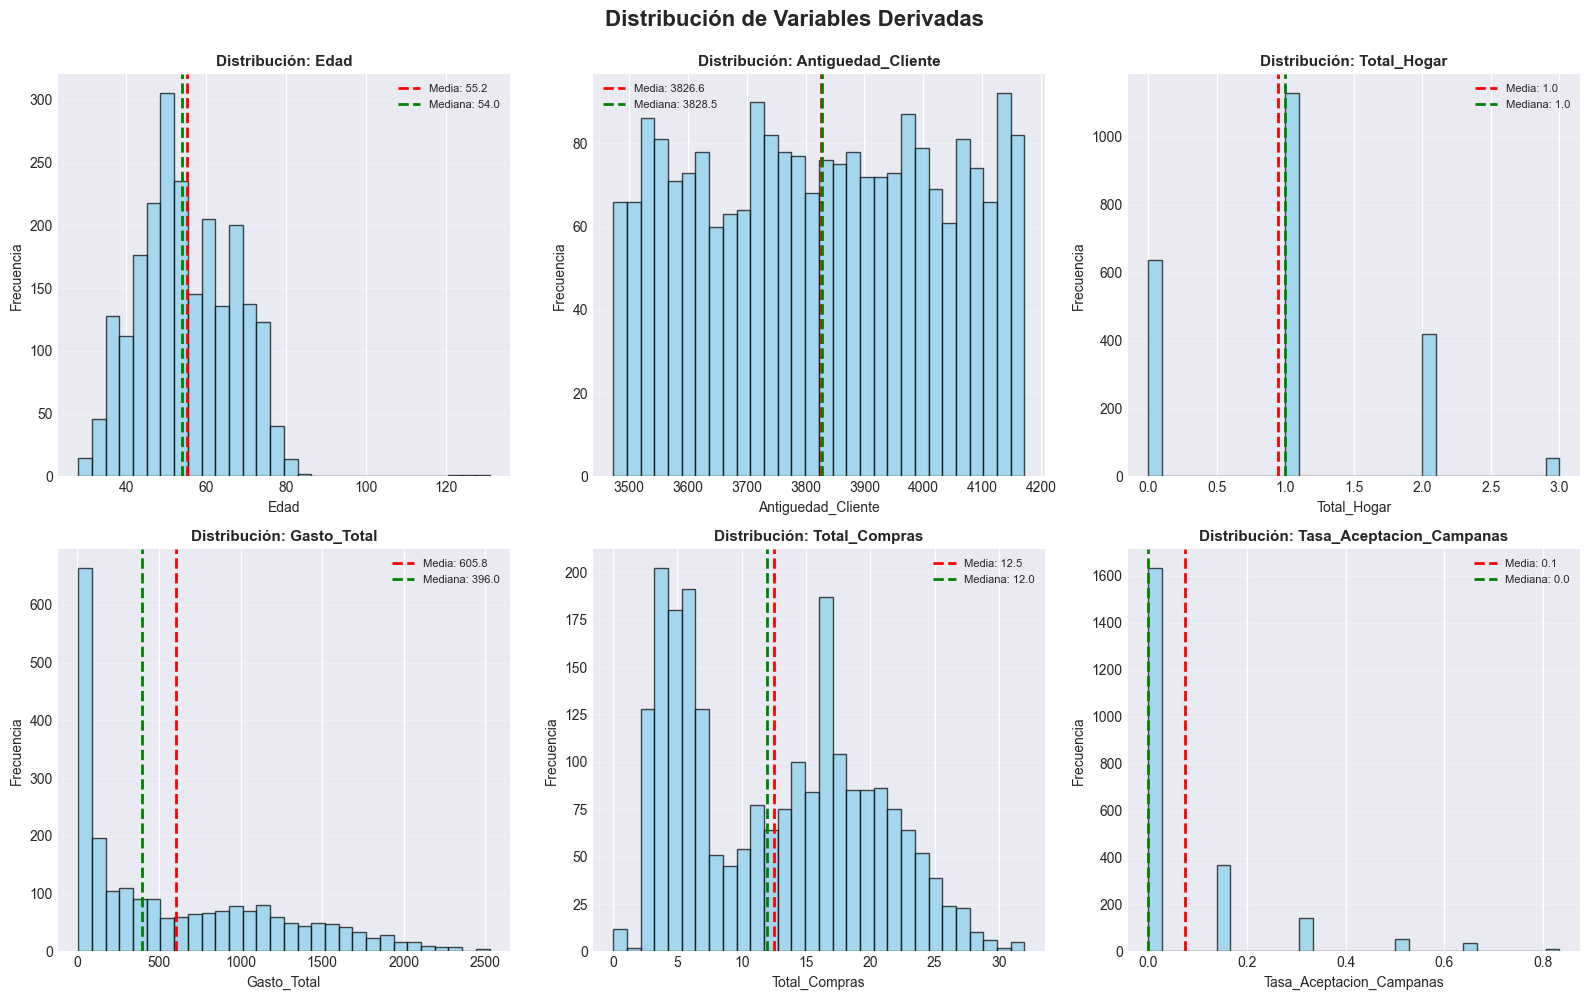

In [23]:
# Visualizar distribuciones de las nuevas variables
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

nuevas_vars = ['Edad', 'Antiguedad_Cliente', 'Total_Hogar', 'Gasto_Total', 'Total_Compras', 'Tasa_Aceptacion_Campanas']

for i, var in enumerate(nuevas_vars):
    if var in df_clean.columns:
        axes[i].hist(df_clean[var], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Distribución: {var}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel(var, fontsize=10)
        axes[i].set_ylabel('Frecuencia', fontsize=10)
        axes[i].grid(alpha=0.3, axis='y')
        
        # Agregar líneas de media y mediana
        media = df_clean[var].mean()
        mediana = df_clean[var].median()
        axes[i].axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.1f}')
        axes[i].axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.1f}')
        axes[i].legend(fontsize=8)

plt.suptitle('Distribución de Variables Derivadas', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

---

## Resumen Final y Exportación

In [24]:
# Comparación antes y después
print("=" * 80)
print("COMPARACIÓN: DATASET ORIGINAL VS DATASET LIMPIO")
print("=" * 80)

print(f"\n📊 DIMENSIONES:")
print(f"   Original:  {filas_original} filas x {columnas_original} columnas")
print(f"   Limpio:    {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")
print(f"   Cambio:    {df_clean.shape[0] - filas_original:+d} filas, {df_clean.shape[1] - columnas_original:+d} columnas")

print(f"\n📊 CALIDAD DE DATOS:")
print(f"   Missing values original:  {df.isna().sum().sum()}")
print(f"   Missing values limpio:    {df_clean.isna().sum().sum()}")
print(f"   Duplicados eliminados:    {filas_original - df_clean.shape[0]}")

print(f"\n📊 NUEVAS VARIABLES:")
nuevas_columnas = ['Edad', 'Antiguedad_Cliente', 'Total_Hogar', 'Gasto_Total', 'Total_Compras', 'Tasa_Aceptacion_Campanas']
print(f"   Variables creadas: {len([v for v in nuevas_columnas if v in df_clean.columns])}")
for col in nuevas_columnas:
    if col in df_clean.columns:
        print(f"   - {col}")

print("\n" + "=" * 80)

COMPARACIÓN: DATASET ORIGINAL VS DATASET LIMPIO

📊 DIMENSIONES:
   Original:  2240 filas x 28 columnas
   Limpio:    2240 filas x 34 columnas
   Cambio:    +0 filas, +6 columnas

📊 CALIDAD DE DATOS:
   Missing values original:  24
   Missing values limpio:    0
   Duplicados eliminados:    0

📊 NUEVAS VARIABLES:
   Variables creadas: 6
   - Edad
   - Antiguedad_Cliente
   - Total_Hogar
   - Gasto_Total
   - Total_Compras
   - Tasa_Aceptacion_Campanas



In [25]:
# Exportar dataset limpio
output_file = 'marketing_data_clean.csv'
df_clean.to_csv(output_file, index=False)

print("=" * 80)
print("EXPORTACIÓN COMPLETADA")
print("=" * 80)
print(f"\n✅ Dataset limpio exportado exitosamente")
print(f"   Archivo: {output_file}")
print(f"   Tamaño: {df_clean.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")
print(f"   Registros: {len(df_clean):,}")
print(f"   Columnas: {len(df_clean.columns)}")

EXPORTACIÓN COMPLETADA

✅ Dataset limpio exportado exitosamente
   Archivo: marketing_data_clean.csv
   Tamaño: 0.88 MB
   Registros: 2,240
   Columnas: 34


## Hallazgos Principales

### 1. Calidad de los Datos
- Se identificaron y trataron valores faltantes en las columnas relevantes
- Se eliminaron registros duplicados para mantener la integridad de los datos
- Se detectaron outliers en varias variables numéricas (ingresos, gastos, edad)

### 2. Variables Derivadas Creadas
1. **Edad**: Calculada a partir del año de nacimiento
2. **Antigüedad_Cliente**: Días desde el registro del cliente
3. **Total_Hogar**: Suma de niños y adolescentes en el hogar
4. **Gasto_Total**: Suma de gastos en todas las categorías de productos
5. **Total_Compras**: Suma de compras en todos los canales
6. **Tasa_Aceptacion_Campanas**: Proporción de campañas aceptadas

### 3. Próximos Pasos (Bonus Opcional)
- Análisis exploratorio de patrones de gasto
- Segmentación de clientes
- Análisis de efectividad de campañas
- Análisis de canales de venta

---

**Dataset limpio listo para análisis avanzados** ✅
